# Spotify Recommender System – Part 1: Exploratory Data Analysis
**Author:** Miguel Vásquez  
**Date:** 19 September 2025  

---

## 1. Introduction  

Music recommendation is one of the most popular and challenging applications of recommender systems. With millions of playlists created daily, streaming platforms such as **Spotify** must provide accurate and personalized suggestions that enhance user experience and engagement.

In this project, we focus on building a **Recommender System** using data derived from the **Spotify Million Playlist Dataset (MPD)**, originally released for the **RecSys Challenge 2018**. The MPD contains **1 million playlists** created between January 2010 and October 2017, including track metadata, playlist titles, and editing information.

To balance **scalability** and **practicality** for research and reproducibility, we construct a **subset of 150,000 playlists** from the original MPD. This subset is large enough to capture the diversity of user behavior while remaining feasible to train models on platforms such as Kaggle.

The main objectives of this project are:
1. Perform exploratory data analysis (EDA) on the Spotify playlists subset.
2. Implement recommendation models, ranging from **baseline heuristics** to **collaborative filtering** and **deep learning-based approaches**.
3. Evaluate models using ranking-aware metrics such as **Precision@K, Recall@K**, and **NDCG@K**.
4. Discuss practical considerations like scalability, diversity, and novelty in music recommendations.

---

## 2. Dataset  
### 2.1 Source

The dataset originates from the **Spotify Million Playlist Dataset (RecSys Challenge 2018)**:
- **Reference**:
    Ching-Wei Chen, Paul Lamere, Markus Schedl, and Hamed Zamani. _RecSys Challenge 2018: Automatic Music Playlist Continuation_. Proceedings of the 12th ACM Conference on Recommender Systems (RecSys ’18), 2018.

### 2.2 Subset Construction

From the original **1 million playlists**, we selected the first **150,000 playlists** (150 slice files).
- Original dataset size: ~6 GB compressed, ~90 GB uncompressed.
- Subset size: ~1 GB compressed, ~13 GB uncompressed.
- Format: JSON → later transformed into **Parquet** for efficient processing.

The subset creation process is implemented in `src/data_pipeline.py`, which:
- Downloads and verifies the raw dataset.
- Extracts the required slices.
- Builds a consolidated subset file.
- Provides a reusable loader function for notebooks.

---

## 3. Objectives of this notebook  

In this first notebook, we will:  
- Load and preprocess a subset of the dataset.  
- Explore basic statistics (number of playlists, tracks, artists).  
- Visualize data distributions (playlist length, track frequency, artist popularity).  
- Examine sparsity and long-tail patterns in the playlist–track interactions.  

This analysis will provide the foundation for building our baseline and advanced models in the following notebooks.  

---

## 4. Exploratory Data Analysis (EDA)

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Set seaborn style
sns.set_palette("Set3")

### 4.1 Load Subset
We load the **150k subset** created from the Spotify Million Playlist Dataset (MPD). This subse

In [2]:
import sys
from pathlib import Path

# Add the parent directory to sys.path so 'src' can be imported
sys.path.append(str(Path.cwd().parent))

from src.data_pipeline import load_subset
from IPython.display import Markdown, display
import os
# Change working directory to the project root
os.chdir("..")

df = load_subset()
display(Markdown(f"Total playlists: {df.shape[0]}"))
df.head()


Loading subset from data\subset\spotify_million_playlist_dataset.parquet...


Total playlists: 150000

,name,collaborative,pid,modified_at,num_tracks,num_albums,num_followers,tracks,num_edits,duration_ms,num_artists,description
0,Throwbacks,false,0,1493424000,52,47,1,"[{'album_name': 'The Cookbook', 'album_uri': '...",6,11532414,37,None
1,Awesome Playlist,false,1,1506556800,39,23,1,"[{'album_name': 'Eye Of The Tiger', 'album_uri...",5,11656470,21,None
2,korean,false,2,1505692800,64,51,1,"[{'album_name': 'On And On', 'album_uri': 'spo...",18,14039958,31,None
3,mat,false,3,1501027200,126,107,1,"[{'album_name': 'French Festival', 'album_uri'...",4,28926058,86,None
4,90s,false,4,1401667200,17,16,2,[{'album_name': 'Mellon Collie and the Infinit...,7,4335282,16,None


### 4.2 Flatten Tracks for Analysis
Each playlist contains a list of tracks with metadata nested inside the `tracks` column.  
To facilitate analysis of track and artist popularity, we need to **flatten this column** so that each track occupies a single row in a new DataFrame.

The resulting `tracks_df` will have one row per track, with the following fields:
- `playlist_id`: ID of the playlist the track belongs to
- `track_name`: Name of the track
- `artist_name`: Name of the primary artist

In [3]:
tracks_expanded = []
for _, row in df.iterrows():
    for t in row['tracks']:
        tracks_expanded.append({
            "playlist_id": row['pid'],
            "artist_name": t['artist_name'],
            "track_name": t['track_name']
        })

tracks_df = pd.DataFrame(tracks_expanded)
tracks_df.head()

# Ensure subsets folder exists inside data/
os.makedirs("data/subset", exist_ok=True)

# Save flattened tracks for future use
tracks_df.to_parquet("data/subset/tracks_subset.parquet", index=False)
display(Markdown("tracks_subset.parquet saved successfully!"))

tracks_subset.parquet saved successfully!

### 4.3 Basic Statistics
We begin by exploring the **numeric features** of playlists.

In [4]:
df.describe()

,pid,modified_at,num_tracks,num_albums,num_followers,num_edits,duration_ms,num_artists
count,150000.000000,1.500000e+05,150000.000000,150000.000000,150000.000000,150000.000000,1.500000e+05,150000.000000
mean,149246.166667,1.476357e+09,66.627893,49.782493,2.569680,17.841547,1.562660e+07,38.125607
std,60344.263177,3.664580e+07,53.776422,39.981951,111.007789,20.823526,1.284568e+07,30.191055
min,0.000000,1.299629e+09,5.000000,2.000000,1.000000,2.000000,5.115990e+05,3.000000
25%,120499.750000,1.459123e+09,26.000000,20.000000,1.000000,5.000000,6.042120e+06,16.000000
50%,157999.500000,1.490314e+09,49.000000,37.000000,1.000000,10.000000,1.149086e+07,30.000000
75%,195499.250000,1.505520e+09,92.000000,68.000000,1.000000,23.000000,2.149006e+07,52.000000
max,232999.000000,1.509494e+09,250.000000,243.000000,31539.000000,191.000000,3.321802e+08,231.000000


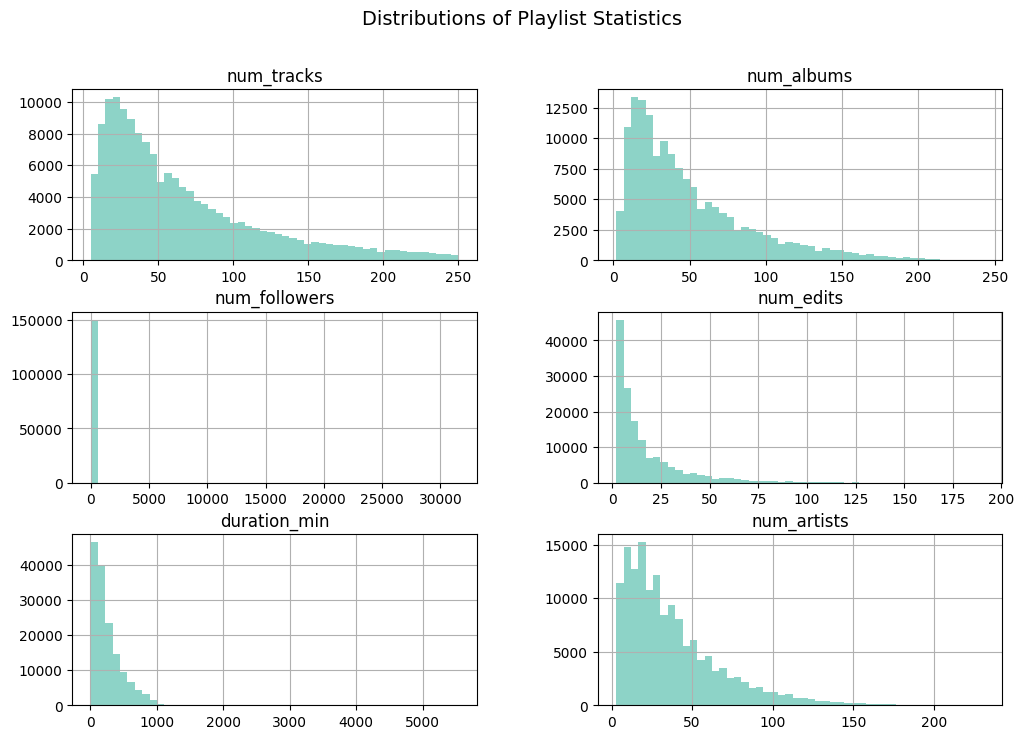

In [5]:
df['duration_min'] = df['duration_ms'] / 60000
numeric_cols = ['num_tracks','num_albums','num_followers','num_edits','duration_min','num_artists']

df[numeric_cols].describe()

df[numeric_cols].hist(bins=50, figsize=(12,8))
plt.suptitle("Distributions of Playlist Statistics", fontsize=14)
plt.show()

#### 4.3.1 Playlist Follower Distribution (log scale)
Follower counts are extremely skewed, with most playlists having very few followers.
Applying a log-transform reveals the long-tail distribution more clearly.

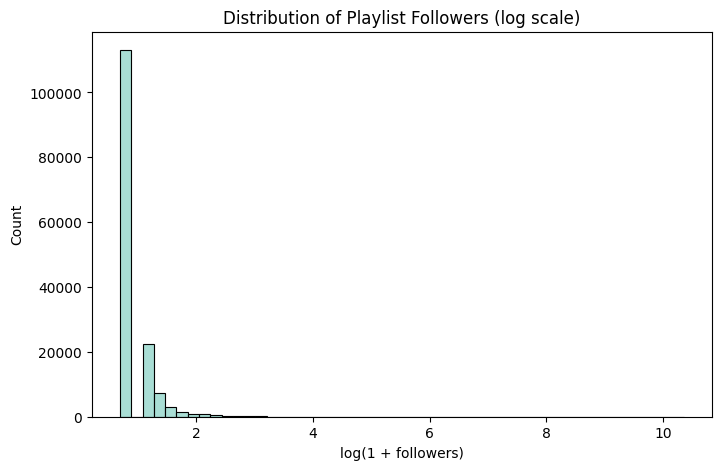

In [6]:
# Log-transform followers
plt.figure(figsize=(8,5))
sns.histplot(x=np.log1p(df['num_followers']), bins=50, kde=False)
plt.title("Distribution of Playlist Followers (log scale)")
plt.xlabel("log(1 + followers)")
plt.ylabel("Count")
plt.show()

### 4.4 Playlist Types
#### Collaborative vs Non-Collaborative

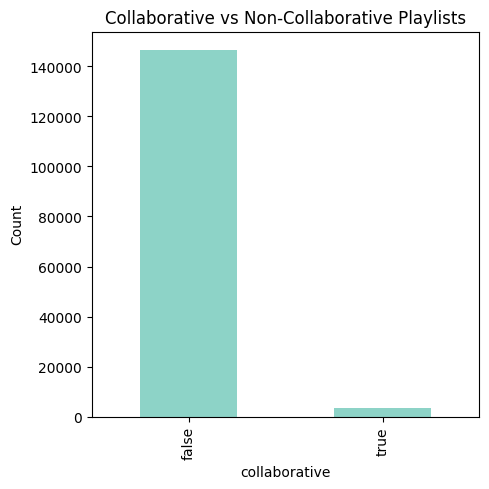

In [7]:
collab_counts = df['collaborative'].value_counts()
plt.figure(figsize=(5,5))
collab_counts.plot(kind="bar")
plt.title("Collaborative vs Non-Collaborative Playlists")
plt.ylabel("Count")
plt.show()


Most playlists are non-collaborative, suggesting that playlist creation is primarily an individual activity rather than collective.

---

### 4.5 Track & Artist Popularity
#### 4.5.1 Top 20 Artists

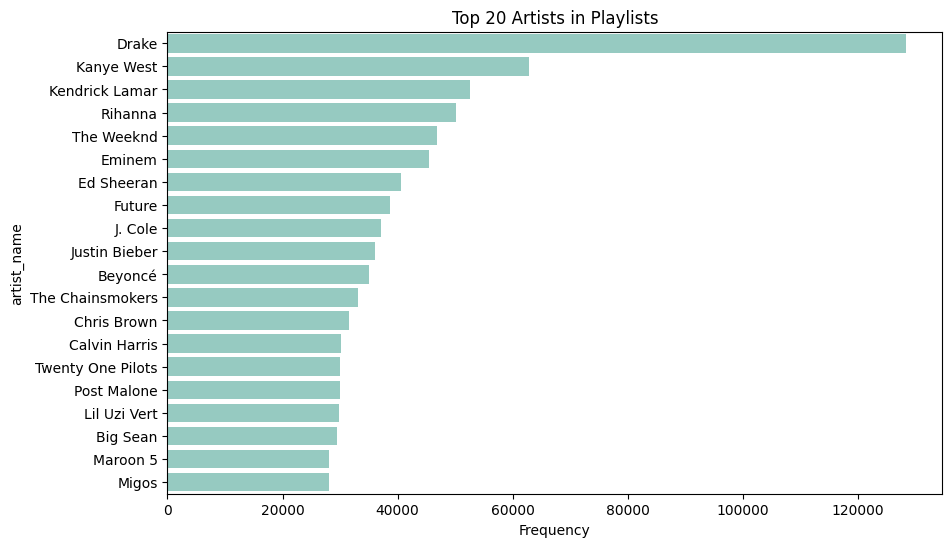

In [8]:
top_artists = tracks_df['artist_name'].value_counts().head(20)
plt.figure(figsize=(10,6))
sns.barplot(x=top_artists.values, y=top_artists.index, orient="h")
plt.title("Top 20 Artists in Playlists")
plt.xlabel("Frequency")
plt.show()

#### 4.5.2 Top 20 Tracks

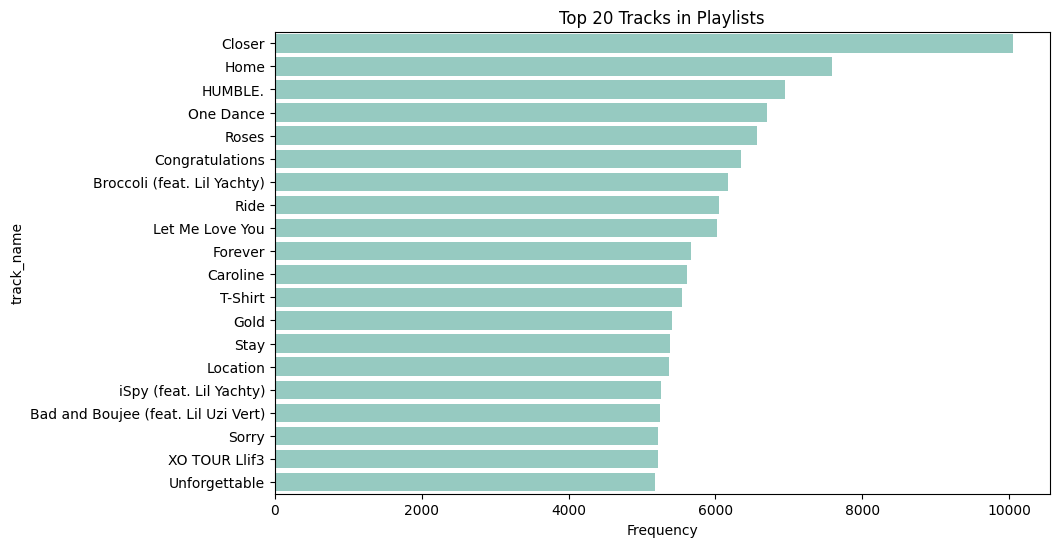

In [9]:
top_tracks = tracks_df['track_name'].value_counts().head(20)
plt.figure(figsize=(10,6))
sns.barplot(x=top_tracks.values, y=top_tracks.index, orient="h")
plt.title("Top 20 Tracks in Playlists")
plt.xlabel("Frequency")
plt.show()

#### 4.5.3 Long-tail Popularity (Log Scale)

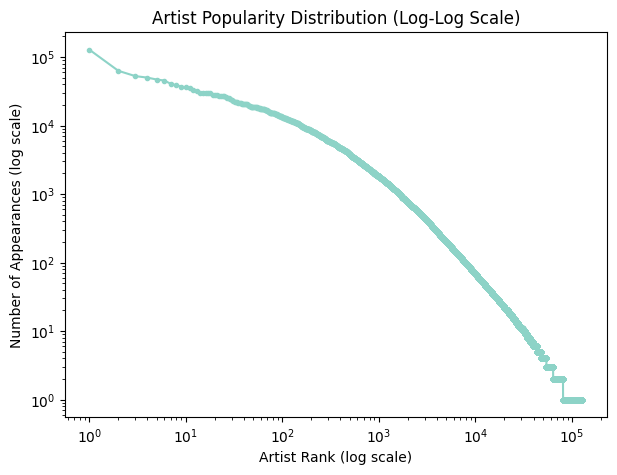

In [10]:
artist_counts = tracks_df['artist_name'].value_counts()
plt.figure(figsize=(7,5))
plt.loglog(range(1, len(artist_counts)+1), artist_counts.values, marker=".")
plt.xlabel("Artist Rank (log scale)")
plt.ylabel("Number of Appearances (log scale)")
plt.title("Artist Popularity Distribution (Log-Log Scale)")
plt.show()

This confirms the long-tail pattern: a few artists dominate, but the majority appear rarely.

---

### 4.6 Highlight Visualizations
#### 4.6.1 Top 20 Playlists by Followers

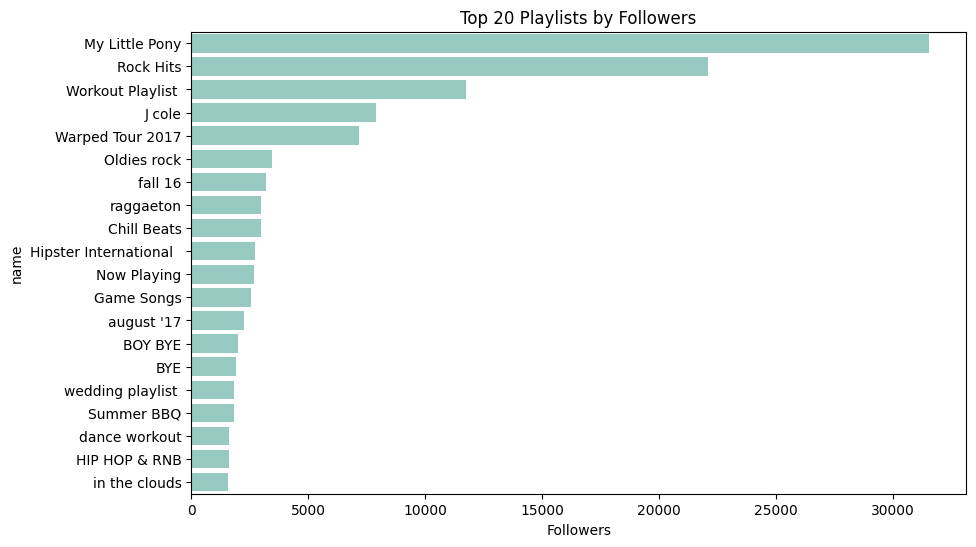

In [11]:
top_playlists = df.sort_values(by="num_followers", ascending=False).head(20)
plt.figure(figsize=(10,6))
sns.barplot(x=top_playlists['num_followers'], y=top_playlists['name'], orient="h")
plt.title("Top 20 Playlists by Followers")
plt.xlabel("Followers")
plt.show()

#### 4.6.2 Violin Plot of Playlist Lengths

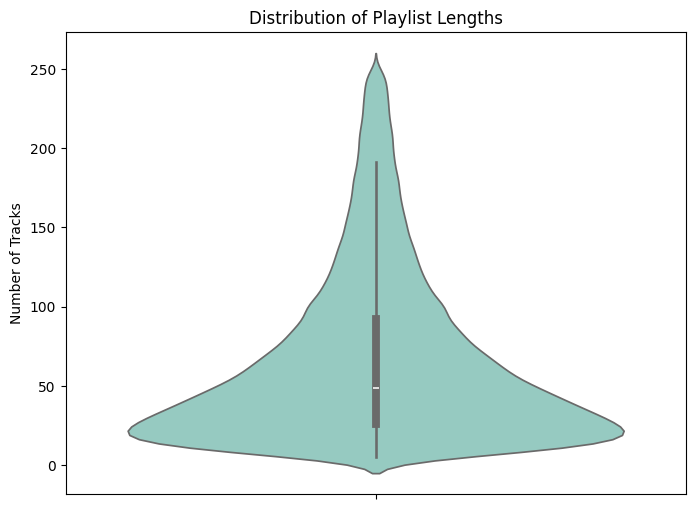

In [12]:
plt.figure(figsize=(8,6))
sns.violinplot(y=df['num_tracks'])
plt.title("Distribution of Playlist Lengths")
plt.ylabel("Number of Tracks")
plt.show()


## 4.7 Summary & Observations
### Key Observations

- **Playlist scale**: Most playlists are short (20–40 tracks), with a few very long playlists.
- **Followers**: Almost all playlists have close to **zero followers**; only a tiny minority attract large audiences.
- **Collaboration**: The overwhelming majority are **non-collaborative**, highlighting playlists as a personal curation tool.
- **Artist dominance**: A small set of artists (e.g., Drake, Kanye West, Rihanna, Eminem) dominate, while most artists appear rarely (classic **long-tail effect**).
- **Track popularity**: Similar concentration is observed in tracks, aligning with the “hit-driven” nature of the music industry.

These findings confirm that music recommendation must balance **popularity bias** (favoring well-known artists) with **diversity and novelty** (surfacing the long-tail).